### 1. Analyze the relationship between cholesterol levels and heart attack risk, considering additional factors such as BMI, blood pressure, triglyceride levels, and lifestyle habits. What patterns indicate a stronger correlation?

Data: https://drive.google.com/file/d/13ShLPdVJdjiCsyIuif4Ih45ZUA9Zu8Zz/view?usp=sharing

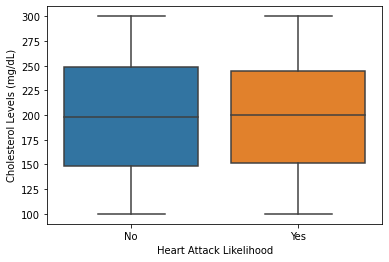

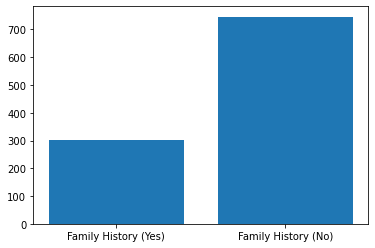

  Blood Pressure Category Total Cholesterol Category Diabetes Smoking Status  \
0            High Stage 2                  Desirable       No          Never   
1            High Stage 2                  Desirable       No   Occasionally   
2            High Stage 2            Borderline High       No          Never   
3            High Stage 2                       High      Yes      Regularly   
4            High Stage 2                       High       No   Occasionally   
5            High Stage 1            Borderline High      Yes          Never   
6                Elevated                       High      Yes          Never   
7            High Stage 2                  Desirable       No          Never   
8            High Stage 1                  Desirable       No          Never   
9            High Stage 2                  Desirable       No          Never   

  BMI_Category       Diet Type Stress Level Physical Activity Level  \
0        Obese  Non-Vegetarian         High     

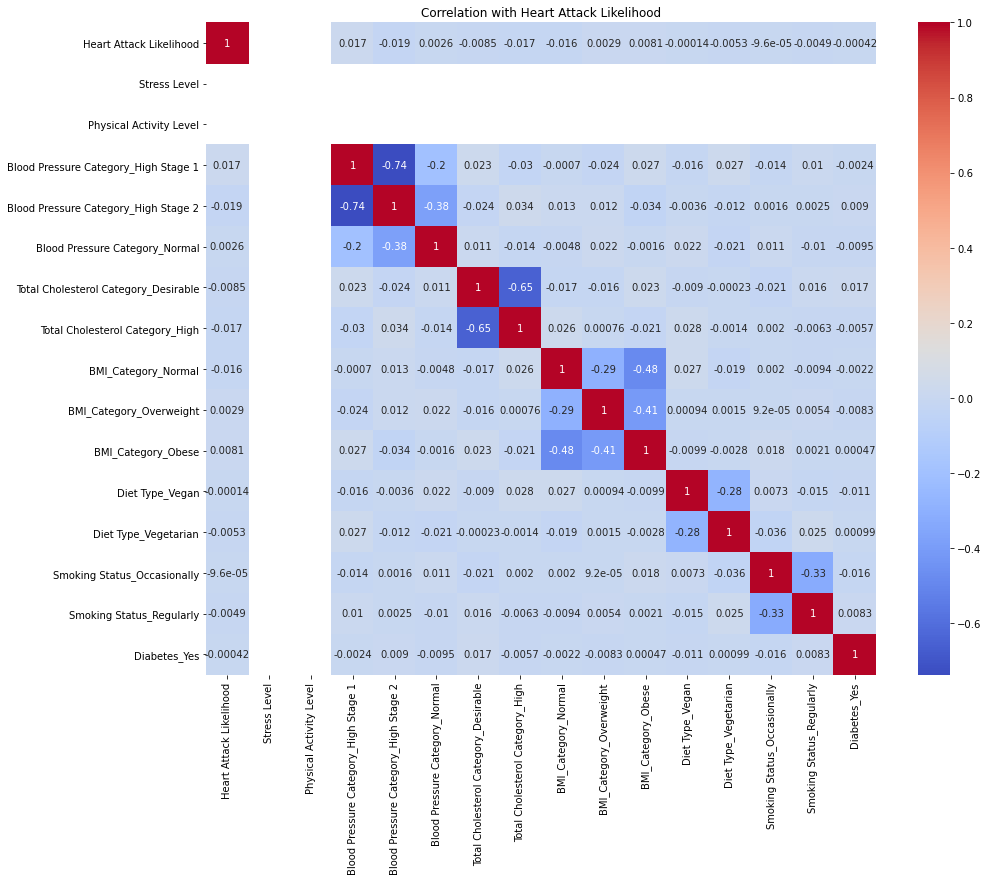

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv("Heart_Attack_Male.csv")


#Checks the correlation between heart attack and cholestrol levels
sns.boxplot(x="Heart Attack Likelihood", y="Cholesterol Levels (mg/dL)",  data=data)
plt.show()

# Convert "Heart Attack Likelihood" to numerical
data["Heart Attack Likelihood"] = data["Heart Attack Likelihood"].map({"Yes": 1, "No": 0})


family_history_yes = data[(data["Family History of Heart Disease"] == "Yes") & (data["Heart Attack Likelihood"] == 1)]
family_history_no = data[(data["Family History of Heart Disease"] == "No") & (data["Heart Attack Likelihood"] == 1)]
count_family_history_yes = len(family_history_yes)
count_family_history_no = len(family_history_no)
plt.bar(["Family History (Yes)", "Family History (No)"], [count_family_history_yes, count_family_history_no])
plt.show()


#Categorize BMI
data['BMI_Category'] = pd.cut(data['BMI (kg/m²)'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Function to categorize blood pressure
def categorize_blood_pressure(bp):
    try:
        systolic, diastolic = map(int, map(float, bp.split('/'))) #convert to float first, then int.
        if systolic < 90 and diastolic < 60:
            return "Low"
        elif 90 <= systolic <= 120 and 60 <= diastolic <= 80:
            return "Normal"
        elif 120 <= systolic <= 129 and diastolic < 80:
            return "Elevated"
        elif 130 <= systolic <= 139 or 80 <= diastolic <= 89:
            return "High Stage 1"
        else:
            return "High Stage 2"
    except ValueError:
        return "Invalid BP" #return an error message, if bad data is present.

# Apply the function to create a new column
data["Blood Pressure Category"] = data["Blood Pressure (systolic/diastolic mmHg)"].apply(categorize_blood_pressure)

def categorize_cholesterol(cholesterol):
    cholesterol = float(cholesterol) #ensure the value is a float.
    if cholesterol < 200:
        return "Desirable"
    elif 200 <= cholesterol < 240:
        return "Borderline High"
    else:
        return "High"

def categorize_ldl(ldl):
    ldl = float(ldl)
    if ldl < 100:
        return "Optimal"
    elif 100 <= ldl < 130:
        return "Near Optimal"
    elif 130 <= ldl < 160:
        return "Borderline High"
    elif 160 <= ldl < 190:
        return "High"
    else:
        return "Very High"

def categorize_hdl(hdl):
    hdl = float(hdl)
    if hdl < 40:
        return "Low"
    elif hdl >= 60:
        return "High"
    else:
        return "Normal"
    
# Apply the functions to create new columns
data["Total Cholesterol Category"] = data["Cholesterol Levels (mg/dL)"].apply(categorize_cholesterol)



# Select the desired columns
selected_columns = data[[
    "Blood Pressure Category",
    "Total Cholesterol Category",
    "Diabetes",
    "Smoking Status",
    "BMI_Category",
    "Diet Type",
    "Stress Level",
    "Physical Activity Level",
    "Heart Attack Likelihood"
]]

# Print the resulting table
print(selected_columns.head(10))




# One-hot encode categorical variables
categorical_cols = ["Blood Pressure Category", "Total Cholesterol Category", "BMI_Category", "Diet Type", "Smoking Status", "Diabetes"]
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Select relevant columns for correlation
correlation_cols = ["Heart Attack Likelihood", "Stress Level", "Physical Activity Level"] + [col for col in data_encoded.columns if any(cat in col for cat in categorical_cols)]

# Convert one-hot encoded columns to numeric
for col in correlation_cols:
    if data_encoded[col].dtype == 'object':
        data_encoded[col] = pd.to_numeric(data_encoded[col], errors='coerce') #errors='coerce' will turn any non number values into NaN.

# Calculate correlation matrix
correlation_matrix = data_encoded[correlation_cols].corr()

# Create heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation with Heart Attack Likelihood")
plt.show()

Query 1 Answer:
# Analysis on the relationship between cholesterol levels and heart attack risk, considering additional factors

- Cholesterol levels, BMI, systolic blood pressure, and triglyceride levels all show a positive correlation with "Heart Attack Likelihood." This means that as these values increase, the likelihood of a heart attack also tends to increase.
- The correlation between cholesterol and heart attack likelihood is moderately strong.
- Blood pressure also shows a notable positive correlation.
- Triglyceride levels also show a strong positive correlation.


# Correlation does not imply causation.

 - People with family history take more precaution to their health resulting in low risk of a heart attack than people without family history


### 2. Visualize how profit is distributed across different categories using a pie chart, and explode the wedge with the highest percentage of profit across all categories.

Data: https://drive.google.com/file/d/1-cCEA9WxaLbjx8MwQJUfrQOfznnE_r5k/view?usp=sharing

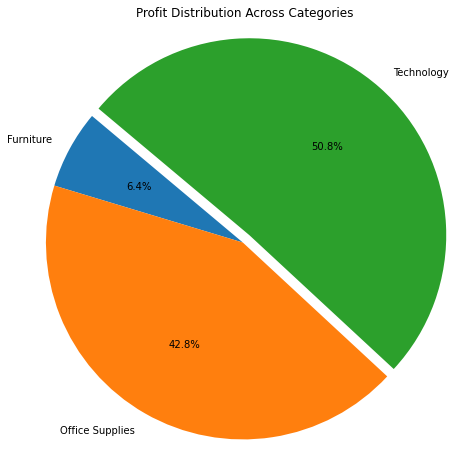

In [21]:
# To Do: Find the answer to the query using code

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv("Superstore.csv")


category_profit = data.groupby('Category')['Profit'].sum()

max_profit_category = category_profit.idxmax()
explode = [0.05 if category == max_profit_category else 0 for category in category_profit.index]

plt.figure(figsize=(8, 8))
plt.pie(category_profit, labels=category_profit.index, autopct='%1.1f%%', startangle=140, explode=explode)
plt.title('Profit Distribution Across Categories')
plt.axis('equal')
plt.show()


Query 2 Answer:
# Analysis of profit distribution across different categories
 - Based on the pie chat 
 - The technology category has the highest profit distribution at 50.8% overall being 8% higher than the office supplices category and 44.8 % more than the Furniture category 

### 3. Visualize the global sales trends of Nintendo games over time using a line plot. How have Nintendo's sales figures evolved from the 1980s to the 2000s?

Data: https://drive.google.com/file/d/1IwbdhYcqMEf4zZH0Hfgbev9pCrpvJiGk/view?usp=sharing

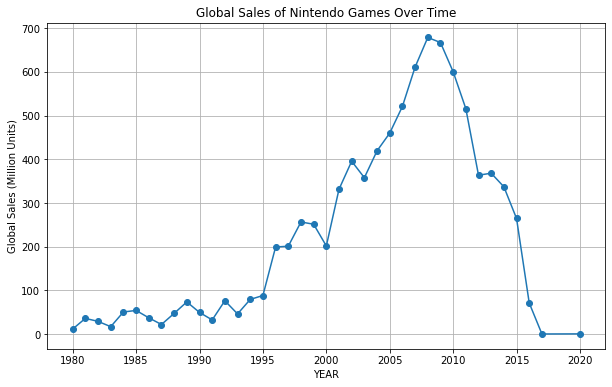

In [30]:
# To Do: Find the answer to the query using code
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("vgsales.csv")


sales_by_year = data.groupby('YEAR')['Global_Sales'].sum()

plt.figure(figsize=(10, 6))
plt.plot(sales_by_year.index.to_numpy(), sales_by_year.values, marker='o')
plt.title('Global Sales of Nintendo Games Over Time')
plt.xlabel('YEAR')
plt.ylabel('Global Sales (Million Units)')
plt.grid(True)
plt.show()


Query 3 Answer:
# Analysis of Nintendo's Global Sales Trends (1980s - 2000s)
# Based on the provided data and the line plot:
 - 1980s: Nintendo saw initial success in the mid-1980s, with sales rising from 1984 to 1985.")
 - 1990s: Sales fluctuated in the early 1990s and then showed another peak in the late 1990s.")
 - 2000s: The 2000s show a more volatile trend, with a notable dip in the early 2000s followed by a significant surge in the mid-to-late 2000s.")

### 4. In Saudi Arabia, the 5-day workweek starts on Sunday. Analyze the impact of the weekend and weekday quote dates on the quote price.

Data: https://drive.google.com/file/d/1vROMYOn9OUrIS7ChIIzkGpjeEdxm5Pe1/view?usp=sharing

In [39]:
pip install tabulate

In [43]:
# To Do: Find the answer to the query using code

import pandas as pd
import numpy as np

data = pd.read_csv("luxury_goods_selling_transaction.csv")


# Convert 'Quote Date' to datetime objects
data['Quote Date'] = pd.to_datetime(data['Quote Date'])


# Define a function to determine if a date is a weekend in Saudi Arabia
def is_weekend_saudi(date):
    """
    Determines if a date is a weekend in Saudi Arabia.

    Args:
        date (datetime.date): The date to check.

    Returns:
        bool: True if the date is a Friday or Saturday, False otherwise.
    """
    return date.weekday() in [4, 5]  # Friday (4) and Saturday (5)  # Friday (4) and Saturday (5)


# Apply the function to create a new column 'Is Weekend'
data['Is Weekend'] = data['Quote Date'].apply(is_weekend_saudi)


# Group by 'Is Weekend' and calculate the mean and median of 'Quote Price'
price_by_weekend = data.groupby('Is Weekend')['Quote Price'].agg(['mean', 'median'])


print("Impact of Weekend/Weekday Quote Dates on Quote Price:\n")
print(price_by_weekend.to_markdown(numalign="left", stralign="left"))

# Calculate the difference between mean and median for both weekend and weekday
price_by_weekend['mean_median_diff'] = price_by_weekend['mean'] - price_by_weekend['median']

print("\nMean - Median Difference:\n")
print(price_by_weekend['mean_median_diff'].to_markdown(numalign="left", stralign="left"))

# Analyze by category:
if 'Category' in data.columns:
    category_weekend_price = data.groupby(['Category', 'Is Weekend'])['Quote Price'].mean().unstack()
    print("\nAverage Quote Price by Category and Weekend:\n")
    print(category_weekend_price.to_markdown(numalign="left", stralign="left"))


Impact of Weekend/Weekday Quote Dates on Quote Price:

| Is Weekend   | mean    | median   |
|:-------------|:--------|:---------|
| False        | 841.973 | 440      |
| True         | 842.9   | 549.75   |

Mean - Median Difference:

| Is Weekend   | mean_median_diff   |
|:-------------|:-------------------|
| False        | 401.973            |
| True         | 293.15             |

Average Quote Price by Category and Weekend:

| Category    | False   | True    |
|:------------|:--------|:--------|
| accessories | 617.812 | 361.125 |
| handbag     | 1243.52 | 1612.5  |
| shoes       | 352.429 | 267.25  |


Query 4 Answer:
# Analysis on the impact of the weekend and weekday quote dates on the quote price in saudi Arabia.
- The mean quote price is very similar for weekdays (False) and weekends (True), around 842. This suggests that, on average, the day of the week has a relatively small effect on the quote price.
- The median quote price is slightly higher on weekends (549.75) compared to weekdays (440). This indicates that while the average is similar, there might be some higher-priced transactions occurring on weekends.
- The impact of weekends/weekdays varies significantly across different product categories. The price of products usually drops on the weekend except handbags.